In [3]:
import pandas as pd
from sympy import false

In [4]:
df=pd.read_csv("data/Reliance.csv")
df

,Date,Open,High,Low,Close,Volume
0,01/07/2002 15:30:00,54.37,55.17,54.07,54.70,870456
1,02/07/2002 15:30:00,54.58,54.75,53.63,53.78,961467
2,03/07/2002 15:30:00,53.76,54.96,53.58,53.99,2370174
3,04/07/2002 15:30:00,54.16,54.55,53.66,53.76,1034747
4,05/07/2002 15:30:00,53.96,54.12,52.80,53.01,2140759
...,...,...,...,...,...,...
4461,27/07/2020 15:30:00,2178.80,2198.80,2127.90,2156.20,37060949
4462,28/07/2020 15:30:00,2156.20,2194.00,2150.65,2177.70,25435618
4463,29/07/2020 15:30:00,2177.90,2182.80,2070.45,2096.65,33536361
4464,30/07/2020 15:30:00,2099.00,2139.70,2072.00,2108.85,33624516


In [5]:
df.head()

,Date,Open,High,Low,Close,Volume
0,01/07/2002 15:30:00,54.37,55.17,54.07,54.70,870456
1,02/07/2002 15:30:00,54.58,54.75,53.63,53.78,961467
2,03/07/2002 15:30:00,53.76,54.96,53.58,53.99,2370174
3,04/07/2002 15:30:00,54.16,54.55,53.66,53.76,1034747
4,05/07/2002 15:30:00,53.96,54.12,52.80,53.01,2140759


In [6]:
df.tail()

,Date,Open,High,Low,Close,Volume
4461,27/07/2020 15:30:00,2178.8,2198.8,2127.90,2156.20,37060949
4462,28/07/2020 15:30:00,2156.2,2194.0,2150.65,2177.70,25435618
4463,29/07/2020 15:30:00,2177.9,2182.8,2070.45,2096.65,33536361
4464,30/07/2020 15:30:00,2099.0,2139.7,2072.00,2108.85,33624516
4465,31/07/2020 15:30:00,2114.5,2129.0,2052.80,2067.10,34593375


In [7]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
sum_close=df["Close"].sum()
days=df["Date"]
print(len(days))

close_average=sum_close/len(days)
print(close_average)

#or you could have directly used the mean method

df["Close"].mean()

4466
505.50165248544556


np.float64(505.50165248544556)

In [9]:
df.groupby(["Date","Close"]).value_counts()

Date                 Close    Open     High     Low      Volume  
01/01/2003 15:30:00  59.96    60.56    60.70    59.82    3385535     1
01/01/2004 15:30:00  114.89   116.78   116.78   114.19   4071252     1
01/01/2008 15:30:00  705.35   715.69   717.92   702.09   1204696     1
01/01/2009 15:30:00  310.71   307.08   312.77   305.86   2856335     1
01/01/2013 15:30:00  416.39   418.02   419.31   415.60   1561532     1
                                                                    ..
31/12/2013 15:30:00  443.38   439.81   444.89   439.37   1304298     1
31/12/2014 15:30:00  441.37   435.85   442.74   435.38   1934955     1
31/12/2015 15:30:00  502.52   496.97   505.04   494.84   4225066     1
31/12/2018 15:30:00  1110.68  1120.29  1123.16  1105.68  7222817     1
31/12/2019 15:30:00  1499.78  1527.46  1529.15  1493.83  10150467    1
Name: count, Length: 4466, dtype: int64

In [10]:
print(df["Close"].max())
idx=df["Close"].idxmax()
print(df.loc[idx])

2177.7
Date      28/07/2020 15:30:00
Open                   2156.2
High                   2194.0
Low                   2150.65
Close                  2177.7
Volume               25435618
Name: 4462, dtype: object


In [11]:
df['Date']=pd.to_datetime(df['Date'],dayfirst=True)
df['Year']=df['Date'].dt.year

df.groupby('Year')["Close"].mean()


Year
2002      52.644960
2003      72.509522
2004     103.256032
2005     132.136225
2006     247.977571
2007     471.481734
2008     524.096831
2009     459.480041
2010     513.784303
2011     440.452317
2012     382.464089
2013     420.305000
2014     473.157190
2015     453.592683
2016     502.098008
2017     732.541210
2018    1031.094571
2019    1309.361755
2020    1485.602123
Name: Close, dtype: float64

In [12]:
df["Month"]=df["Date"].dt.month

df.groupby("Month")["Close"].mean()

Month
1     517.418451
2     502.571311
3     482.333442
4     519.203343
5     529.108613
6     538.879766
7     546.190095
8     467.165160
9     469.885136
10    489.431361
11    502.396938
12    494.666596
Name: Close, dtype: float64

In [13]:
df["drop"]=df['Close']-df['Open']

df.groupby("Date")["drop"].min()

Date
2002-07-01 15:30:00     0.33
2002-07-02 15:30:00    -0.80
2002-07-03 15:30:00     0.23
2002-07-04 15:30:00    -0.40
2002-07-05 15:30:00    -0.95
                       ...  
2020-07-27 15:30:00   -22.60
2020-07-28 15:30:00    21.50
2020-07-29 15:30:00   -81.25
2020-07-30 15:30:00     9.85
2020-07-31 15:30:00   -47.40
Name: drop, Length: 4466, dtype: float64

In [14]:
idx_min=df["drop"].idxmin()
print(df.loc[idx_min])

Date      2020-03-09 15:30:00
Open                  1228.36
High                   1229.3
Low                   1084.68
Close                 1103.65
Volume               40317808
Year                     2020
Month                       3
drop                  -124.71
Name: 4368, dtype: object


In [15]:
df.groupby("Date")["Volume"].max()

Date
2002-07-01 15:30:00      870456
2002-07-02 15:30:00      961467
2002-07-03 15:30:00     2370174
2002-07-04 15:30:00     1034747
2002-07-05 15:30:00     2140759
                         ...   
2020-07-27 15:30:00    37060949
2020-07-28 15:30:00    25435618
2020-07-29 15:30:00    33536361
2020-07-30 15:30:00    33624516
2020-07-31 15:30:00    34593375
Name: Volume, Length: 4466, dtype: int64

In [16]:
df.sort_values("Volume", ascending=False)[["Date","Volume"]].head(5)

,Date,Volume
4395,2020-04-22 15:30:00,65230894
4453,2020-07-15 15:30:00,64458598
4397,2020-04-24 15:30:00,61711388
888,2006-01-18 15:30:00,61000244
4460,2020-07-24 15:30:00,55656793


In [17]:
df.groupby("Month")["Volume"].mean().sort_values(ascending=False)

Month
3     5.935618e+06
4     5.800579e+06
1     5.735282e+06
6     5.688965e+06
7     5.684984e+06
5     5.654124e+06
10    5.327241e+06
9     5.105531e+06
2     4.980795e+06
11    4.958735e+06
12    4.901642e+06
8     4.570792e+06
Name: Volume, dtype: float64

In [18]:
df.groupby("Year")[["Open","Close"]].mean()

,Open,Close
Year,,
2002,52.734960,52.644960
2003,72.401195,72.509522
2004,103.716032,103.256032
2005,132.221365,132.136225
2006,247.710000,247.977571
2007,470.955403,471.481734
2008,526.956543,524.096831
2009,459.654025,459.480041
2010,515.019801,513.784303


In [19]:
growth=df.groupby("Year")[["Open","Close"]].mean().diff()

In [20]:
print(growth.idxmax())
print(growth.idxmin())

Open     2018
Close    2018
dtype: int32
Open     2011
Close    2011
dtype: int32


In [21]:
import matplotlib.pyplot as plt

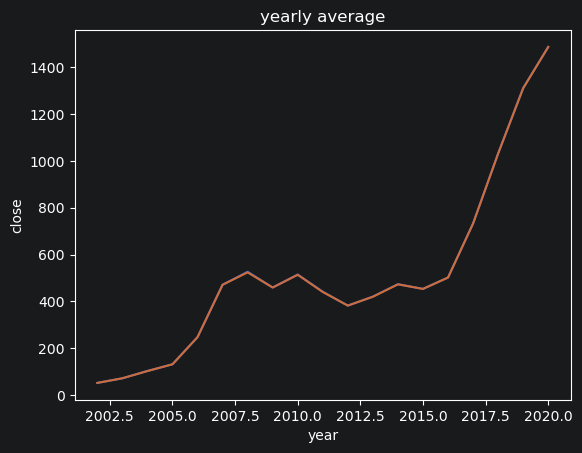

In [22]:
yearly=df.groupby("Year")[["Open","Close"]].mean()
plt.plot(yearly.index,yearly.values)

plt.title("yearly average")
plt.xlabel("year")
plt.ylabel("close")
plt.show()

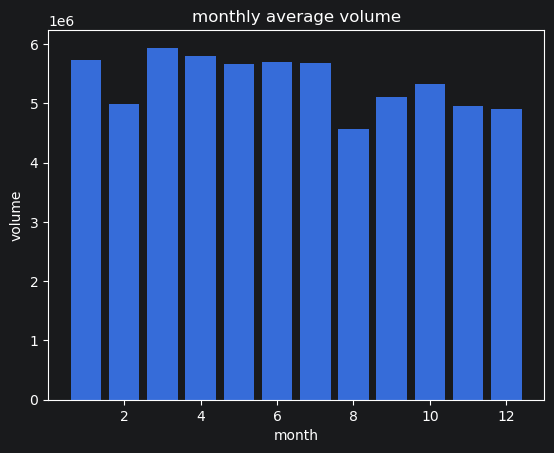

In [23]:
monthly_volume=df.groupby(["Month"])["Volume"].mean()

plt.bar(monthly_volume.index,monthly_volume.values)
plt.title("monthly average volume")
plt.xlabel("month")
plt.ylabel("volume")
plt.show()


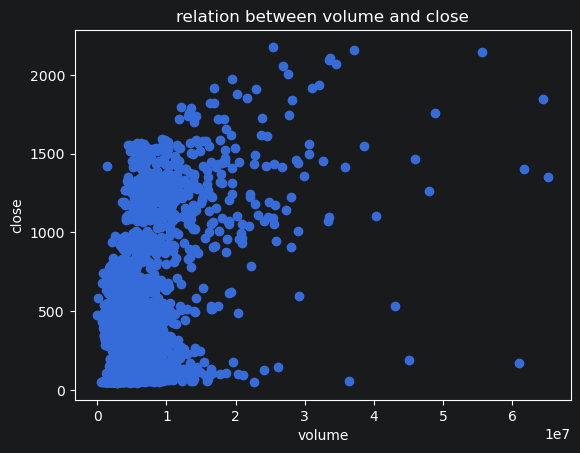

In [24]:
plt.scatter(df["Volume"],df["Close"])
plt.title("relation between volume and close")
plt.xlabel("volume")
plt.ylabel("close")
plt.show()

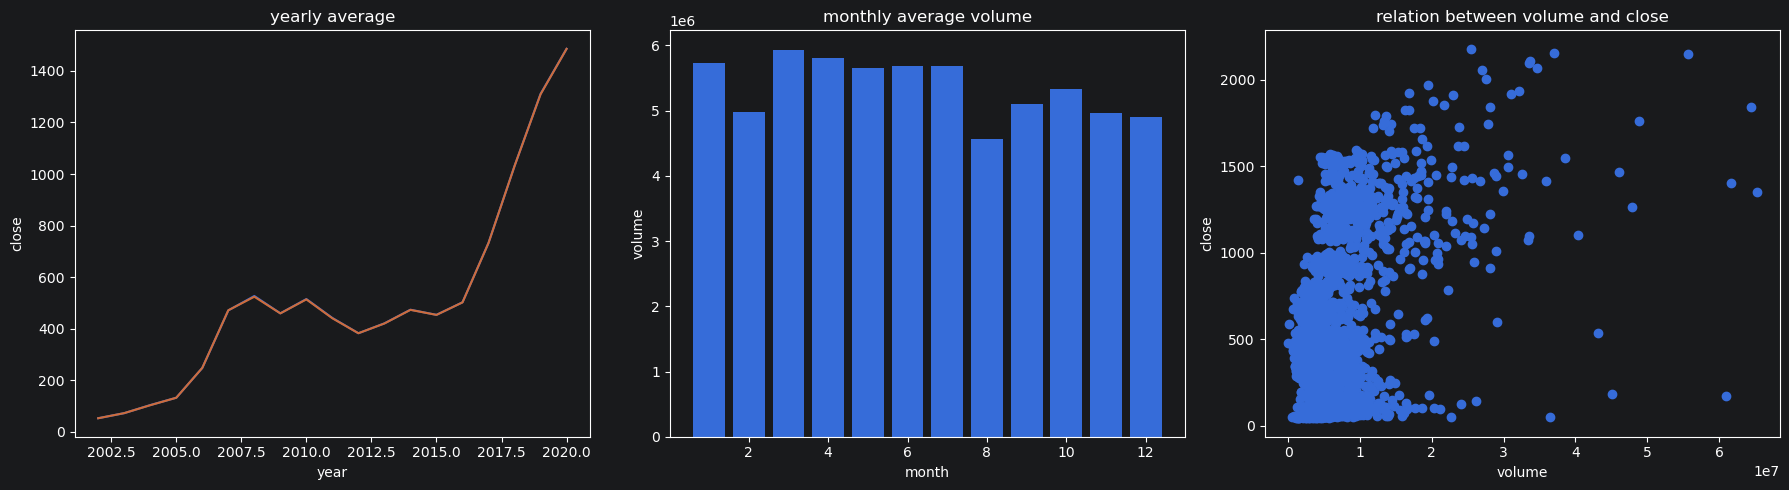

In [25]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.plot(yearly.index,yearly.values)
plt.title("yearly average")
plt.xlabel("year")
plt.ylabel("close")
plt.tight_layout()

plt.subplot(1,3,2)
plt.bar(monthly_volume.index,monthly_volume.values)
plt.title("monthly average volume")
plt.xlabel("month")
plt.ylabel("volume")
plt.tight_layout()

plt.subplot(1,3,3)
plt.scatter(df["Volume"],df["Close"])
plt.title("relation between volume and close")
plt.xlabel("volume")
plt.ylabel("close")

plt.tight_layout()
plt.show()



In [26]:
import seaborn as sns

<Axes: >

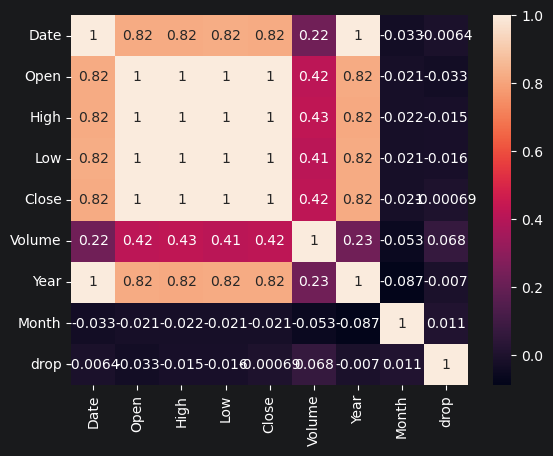

In [27]:
sns.heatmap(data=df.corr(),annot=True)

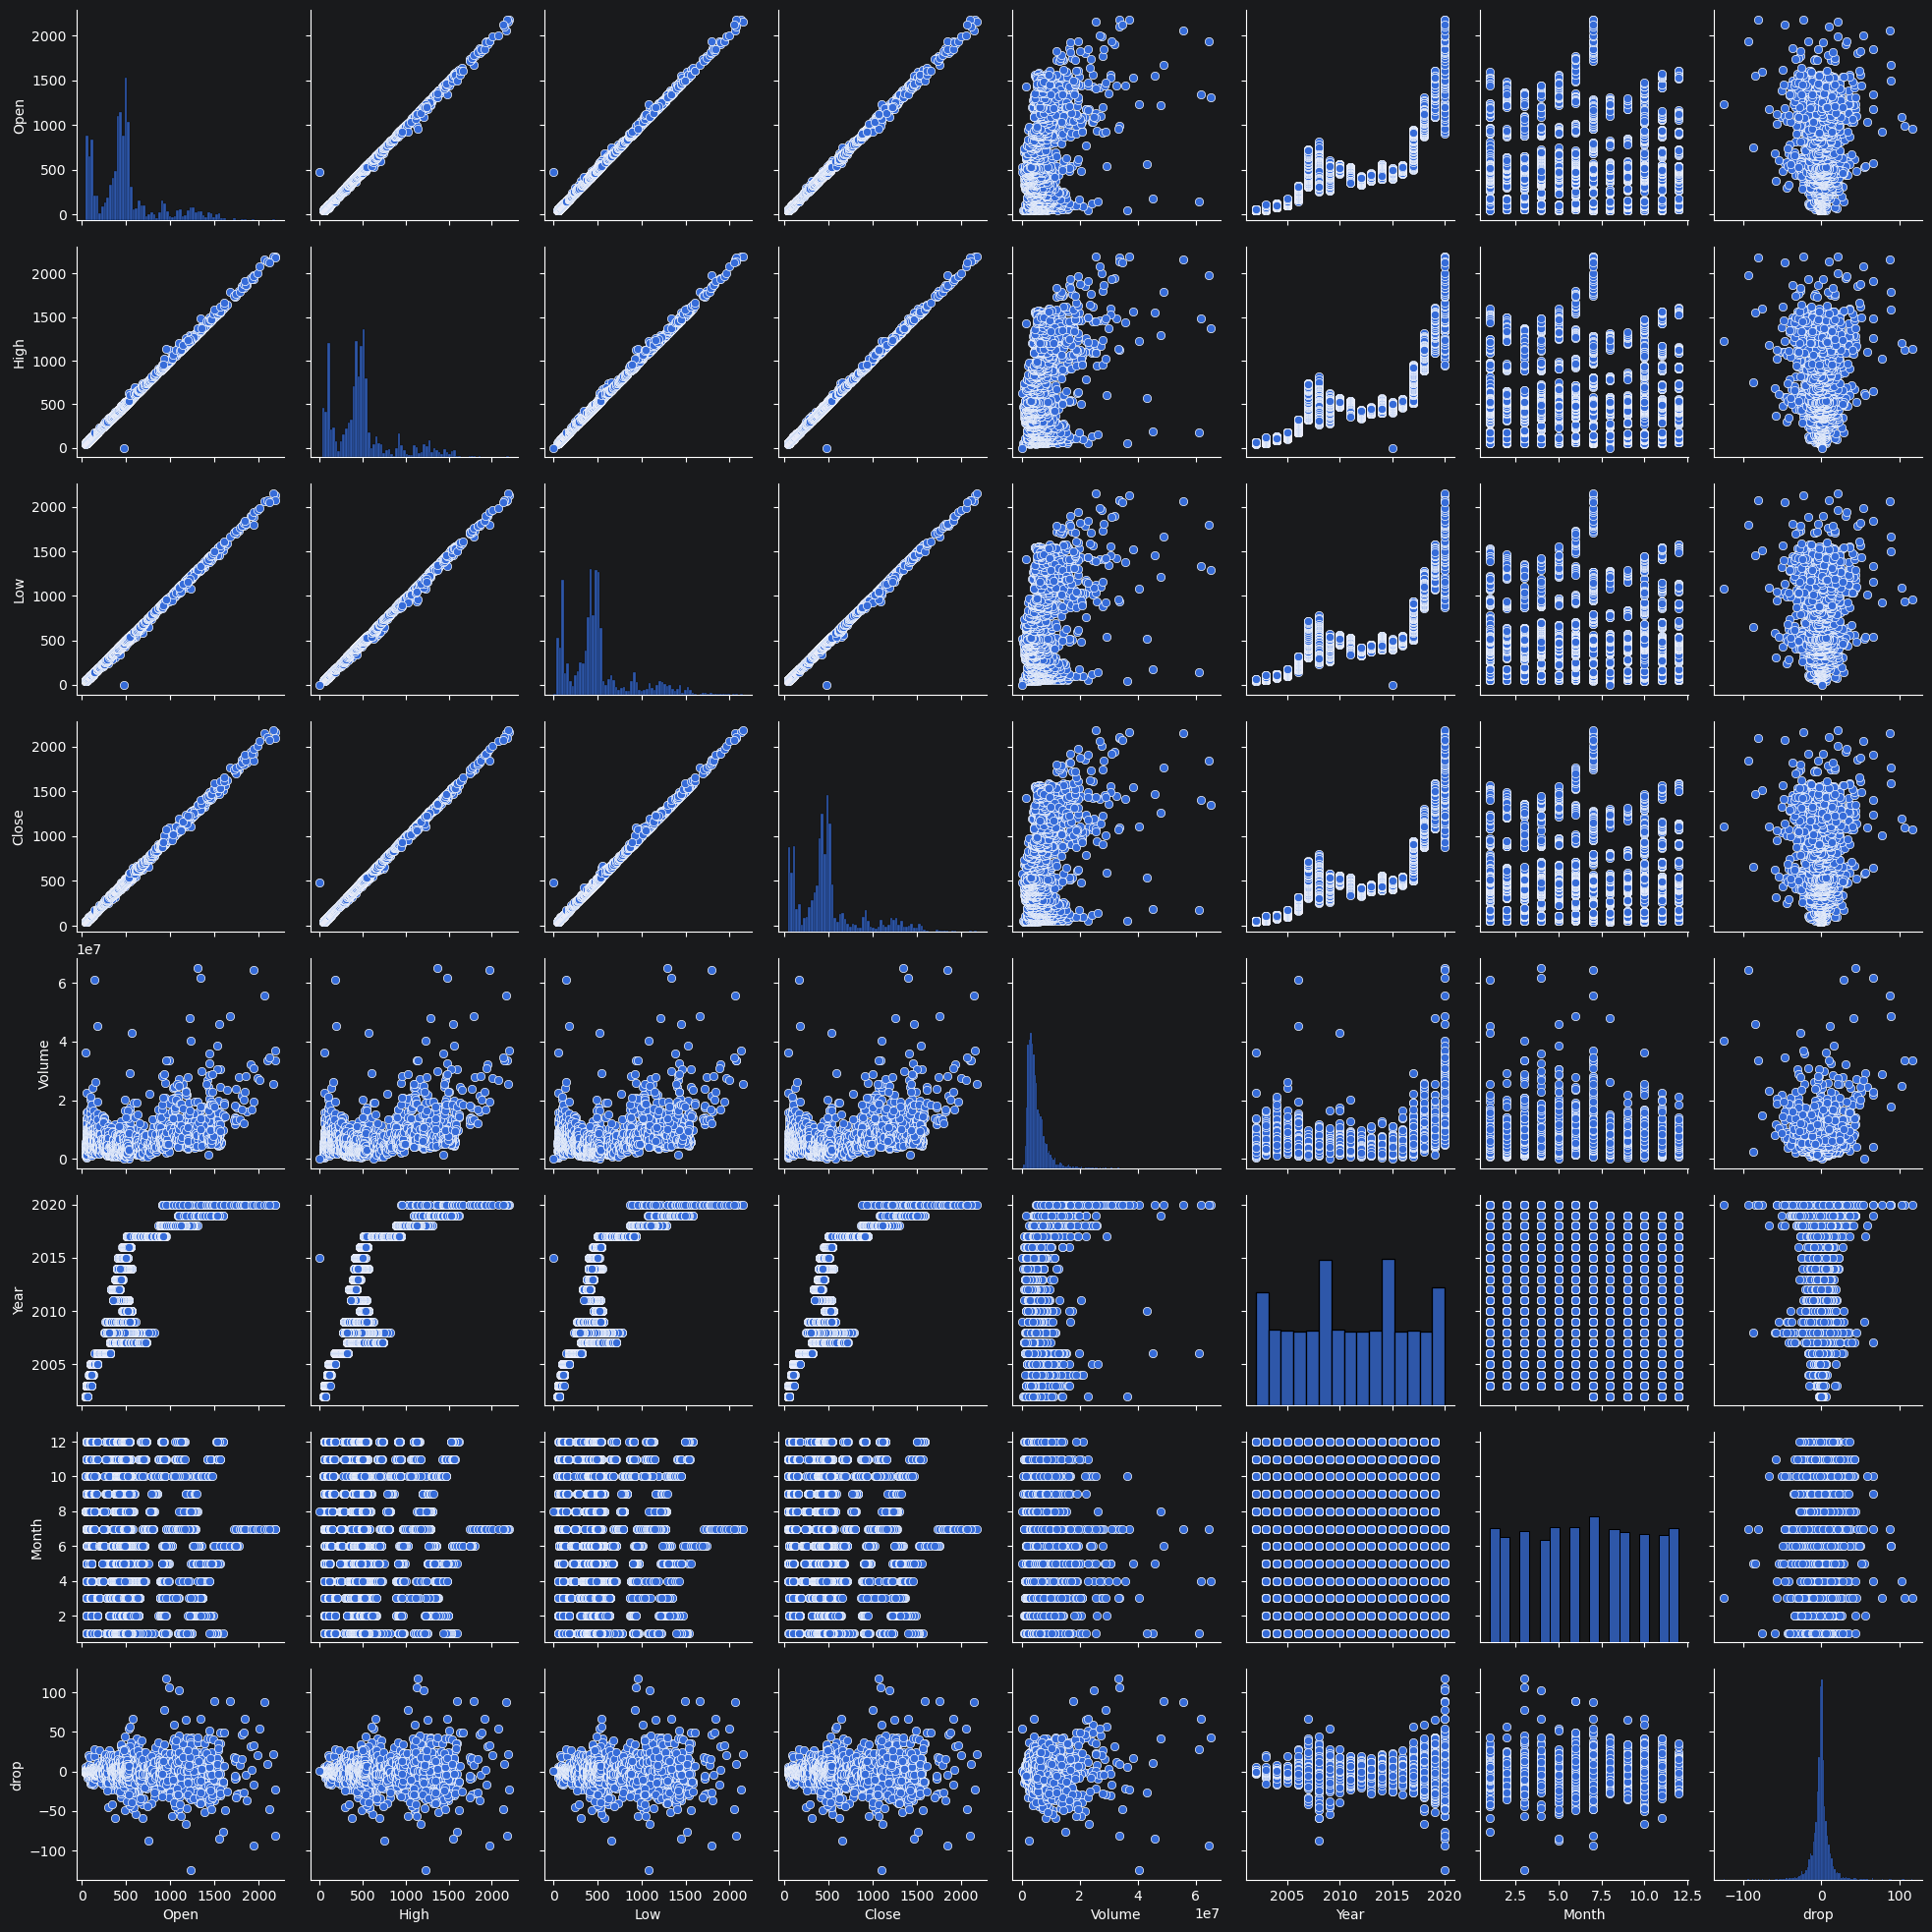

In [28]:
sns.pairplot(df)

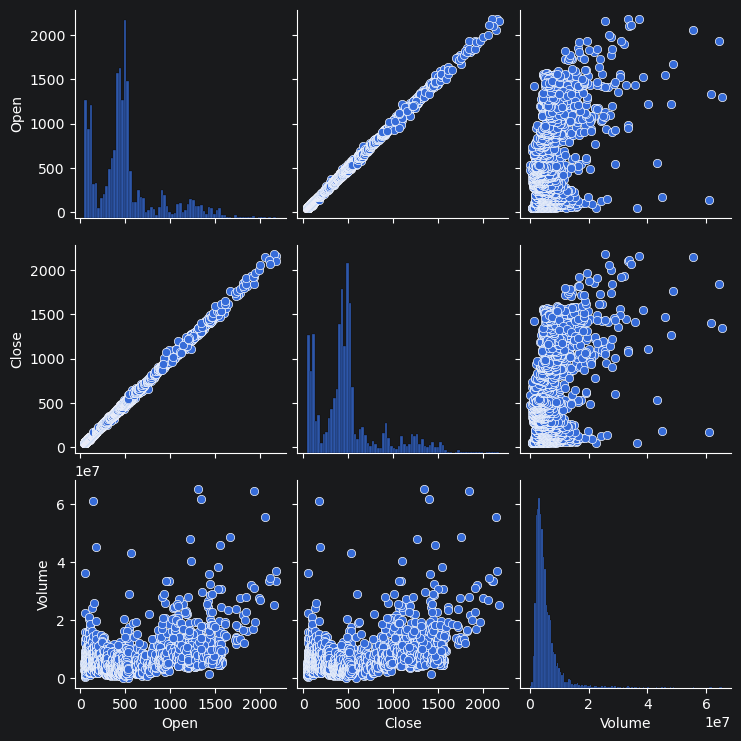

In [33]:
sns.pairplot(df[["Open","Close","Volume"]])

<Axes: ylabel='Close'>

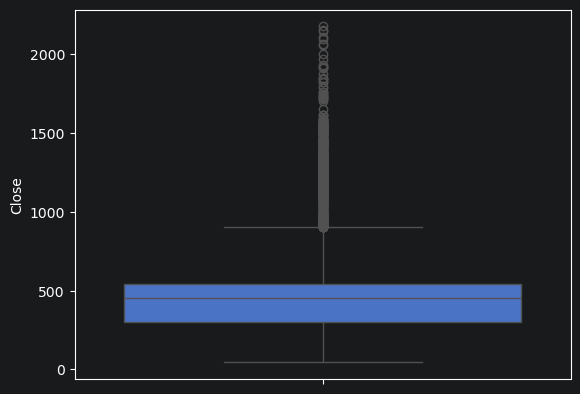

In [34]:
sns.boxplot(y=df["Close"])